# 03 — Riemannian pipelines

Covariance matrices live on a Riemannian manifold; treating them with Euclidean tools throws information away. For ≤100-trial MI problems Riemannian classifiers are typically the strongest baseline.

Two pipelines here:

1. **MDM** — Minimum Distance to Mean on the manifold (no training knobs, extremely data-efficient).
2. **TangentSpace + LogisticRegression** — project covariances to tangent space then a regularised linear classifier.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from pyriemann.estimation import Covariances
from pyriemann.classification import MDM
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from utils.data import load_xdf_epochs
from utils.eval import cv_score, save_result, RESULTS_DIR
from utils.plot import plot_confusion

X, y, classes = load_xdf_epochs('../visionpro-ml.xdf')
print('X:', X.shape, ' y:', y.shape, ' classes:', classes)

X: (90, 4, 625)  y: (90,)  classes: {0: 'left', 1: 'right', 2: 'both'}


## Pipeline A — MDM

In [2]:
def make_mdm():
    return Pipeline([
        ('cov', Covariances(estimator='oas')),
        ('mdm', MDM(metric=dict(mean='riemann', distance='riemann'))),
    ])

def fp_mdm(X_tr, y_tr, X_val, y_val):
    pipe = make_mdm()
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_val)

res_mdm = cv_score(fp_mdm, X, y, n_splits=5, seed=42)
print('MDM           ',
      f"acc={res_mdm['accuracy']:.3f}",
      f"f1={res_mdm['f1_macro']:.3f}")

MDM            acc=0.244 f1=0.197


## Pipeline B — TangentSpace + LR

Small C sweep since the feature space is low-dim (4×4 covariances ⇒ 10 tangent features).

In [3]:
def make_ts(C=0.1):
    return Pipeline([
        ('cov', Covariances(estimator='oas')),
        ('ts', TangentSpace(metric='riemann')),
        ('lr', LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                                   max_iter=1000)),
    ])

rows = []
for C in (0.01, 0.1, 1.0, 10.0):
    def _fp(X_tr, y_tr, X_val, y_val, C=C):
        pipe = make_ts(C=C)
        pipe.fit(X_tr, y_tr)
        return pipe.predict(X_val)
    r = cv_score(_fp, X, y)
    rows.append({'C': C, 'acc': r['accuracy'], 'f1': r['f1_macro']})
df = pd.DataFrame(rows)
df

/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

,C,acc,f1
0,0.01,0.200000,0.160526
1,0.10,0.166667,0.155402
2,1.00,0.200000,0.185356
3,10.00,0.222222,0.214066


In [4]:
best_C = df.loc[df['f1'].idxmax(), 'C']
def fp_ts(X_tr, y_tr, X_val, y_val):
    pipe = make_ts(C=best_C)
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_val)

res_ts = cv_score(fp_ts, X, y, n_splits=5, seed=42)
print(f"TangentSpace+LR (C={best_C})",
      f"acc={res_ts['accuracy']:.3f}",
      f"f1={res_ts['f1_macro']:.3f}")

/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


TangentSpace+LR (C=10.0) acc=0.222 f1=0.214


/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


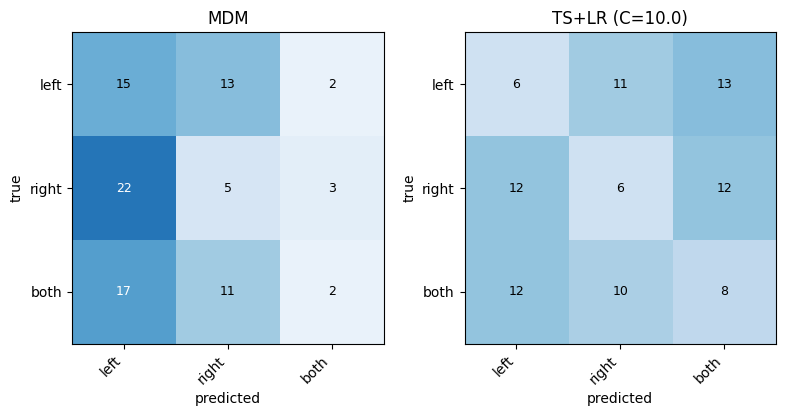

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_confusion(np.array(res_mdm['confusion']), classes, ax=axes[0], title='MDM')
plot_confusion(np.array(res_ts['confusion']), classes, ax=axes[1],
               title=f'TS+LR (C={best_C})')
plt.tight_layout(); plt.show()

In [6]:
save_result('03_mdm', res_mdm, classes)
save_result('03_tangent_lr', res_ts, classes)

final_mdm = make_mdm(); final_mdm.fit(X, y)
final_ts  = make_ts(C=best_C); final_ts.fit(X, y)
joblib.dump({'pipeline': final_mdm, 'classes': classes}, RESULTS_DIR / '03_mdm.joblib')
joblib.dump({'pipeline': final_ts, 'classes': classes, 'C': best_C},
            RESULTS_DIR / '03_tangent_lr.joblib')
print('saved both')

saved both


/Users/macuser/Downloads/EEG Classifier/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
